### [Data Wrangling & Visualization](https://medium.com/@alexzap922/using-skforecast-for-multiple-ml-time-series-forecasting-tsf-across-industries-1-d19b893c85c6)

> Use-Case Analysis of Skforecast TSF, Backtesting, Hyperparameter Optimization (HPO) and ML Evaluation Modules in Python

Following 16 built-in datasets are available in `Skforecast`:

1. `fuel_consumption`
-----------------
Monthly fuel consumption in Spain from 1969-01-01 to 2022-08-01.

2. `Monthly AUS Drug Expenditure`
-----------------
Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health
system had between 1991 and 2008.

3. `items_sales`
-----------
Simulated time series for the sales of 3 different items.

4. `air_quality_valencia`
--------------------
Hourly measures of several air chemical pollutant at Valencia city (Avd.
Francia) from 2019-01-01 to 20213-12-31. Including the following variables:
pm2.5 (µg/m³), CO (mg/m³), NO (µg/m³), NO2 (µg/m³), PM10 (µg/m³), NOx (µg/m³),
O3 (µg/m³), Veloc. (m/s), Direc. (degrees), SO2 (µg/m³).
Red de Vigilancia y Control de la Contaminación Atmosférica, 46250047-València -
Av. França

5. `website_visits`
--------------
Daily visits to the cienciadedatos.net website registered with the google
analytics service.
Amat Rodrigo, J. (2021). cienciadedatos.net (1.0.0). Zenodo.
https://doi.org/10.5281/zenodo.10006330

6. `bike_sharing`
------------
Hourly usage of the bike share system in the city of Washington D.C. during the
years 2011 and 2012. In addition to the number of users per hour, information
about weather conditions and holidays is available.
Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.
https://doi.org/10.24432/C5W894.

7. `australia_tourism`
-----------------
Overnight trips (in thousands) from 1998 to 2017 across
Australia. The tourism regions are formed through the aggregation of Statistical
Local Areas (SLAs) which are defined by the various State and Territory tourism
authorities according to their research and marketing needs.
Wang, E, D Cook, and RJ Hyndman (2020). A new tidy data structure to support
exploration and modeling of temporal data, Journal of Computational and
Graphical Statistics, 29:3, 466-478, doi:10.1080/10618600.2019.1695624.

8. `uk_daily_flights`
----------------
Daily number of flights in UK from 02/01/2019 to 23/01/2022.
Experimental statistics published as part of the Economic activity and social
change in the UK, real-time indicators release, Published 27 January 2022. Daily
flight numbers are available in the dashboard provided by the European
Organisation for the Safety of Air Navigation (EUROCONTROL).

9. `wikipedia_visits`
----------------
Log daily page views for the Wikipedia page for Peyton Manning. Scraped data
using the Wikipediatrend package in R.

10. `vic_electricity`
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html

11. `store_sales`
-----------
This dataset contains 913,000 sales transactions from 2013-01-01 to 2017-12-31
for 50 products (SKU) in 10 stores.

12. `bicimad`
-------
This dataset contains the daily users of the bicycle rental service (BiciMad) in
the city of Madrid (Spain) from 2014-06-23 to 2022-09-30.

13. `m4_daily`
--------
Time series with daily frequency from the M4 competition.
This information has been obtainded from the Kaggle competition page:
https://www.kaggle.com/datasets/yogesh94/m4-forecasting-competition-dataset

14. `m4_hourly`
---------
Time series with hourly frequency from the M4 competition.

15. `ashrae_daily`
------------
Daily energy consumption data from the ASHRAE competition with building metadata
and weather data.
Kaggle competition Addison Howard, Chris Balbach, Clayton Miller, Jeff Haberl,
Krishnan Gowri, Sohier Dane. (2019). ASHRAE - Great Energy Predictor III.
Kaggle. https://www.kaggle.com/c/ashrae-energy-prediction/overview

16. `bdg2_daily`
----------
Daily energy consumption data from the The Building Data Genome Project 2 with
building metadata and weather data. 
Miller, C., Kathirgamanathan, A., Picchetti, B. et al. The Building Data Genome
Project 2, energy meter data from the ASHRAE Great Energy Predictor III
competition. Sci Data 7, 368 (2020). https://doi.org/10.1038/s41597-020-00712-x
Shape of the dataset: (1153518, 18)

In [1]:
from dotenv import load_dotenv, dotenv_values
load_dotenv()

True

In [2]:
!pip install -q "numpy==1.26.4" "pandas==2.2.2" statsmodels
!pip install -q matplotlib plotly pmdarima "seaborn>=0.11,<0.14"
!pip install -q skforecast skforecast[plotting]

In [3]:
# Libraries
import numpy as np
import pandas as pd
from io import StringIO
import contextlib
import re
import matplotlib.pyplot as plt
plt.style.use('default')

# pmdarima
import pmdarima as pm
from pmdarima import ARIMA
from pmdarima import auto_arima

# statsmodels
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# skforecast
import skforecast
from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme
from skforecast.sarimax import Sarimax
from skforecast.recursive import ForecasterSarimax
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_sarimax
from skforecast.model_selection import grid_search_sarimax

import warnings
warnings.filterwarnings('ignore')

color = '\033[1m\033[38;5;208m' 
print(f"{color}Version skforecast: {skforecast.__version__}")
print(f"{color}Version pdarima: {pm.__version__}")
print(f"{color}Version statsmodels: {statsmodels.__version__}")
print(f"{color}Version pandas: {pd.__version__}")
print(f"{color}Version numpy: {np.__version__}")

Version skforecast: 0.15.1
Version pdarima: 2.0.4
Version statsmodels: 0.14.4
Version pandas: 2.2.2
Version numpy: 1.26.4


**Skforecast** provides quick access to a large number of both real-world and synthetic datasets that are very useful for generating reproducible use-case examples of TSF across various industry sectors worldwide.

#### Fuel Consumption

In [4]:
data = fetch_dataset(name='fuel_consumption', raw=True)
data.tail()

fuel_consumption
----------------
Monthly fuel consumption in Spain from 1969-01-01 to 2022-08-01.
Obtained from Corporación de Reservas Estratégicas de Productos Petrolíferos and
Corporación de Derecho Público tutelada por el Ministerio para la Transición
Ecológica y el Reto Demográfico. https://www.cores.es/es/estadisticas
Shape of the dataset: (644, 6)


,Fecha,GLPs,Gasolinas,Querosenos,Gasoleos,Fueloleos
639,2022-04-01,179591.64,471601.94,494966.32,2638029.80,636930.42
640,2022-05-01,134166.56,478873.41,530034.01,2673797.49,708289.26
641,2022-06-01,142480.09,501447.14,540594.97,2648087.31,667221.45
642,2022-07-01,135984.49,534584.68,607854.68,2613591.24,691371.60
643,2022-08-01,119104.84,565761.96,596051.08,2572012.22,701384.41


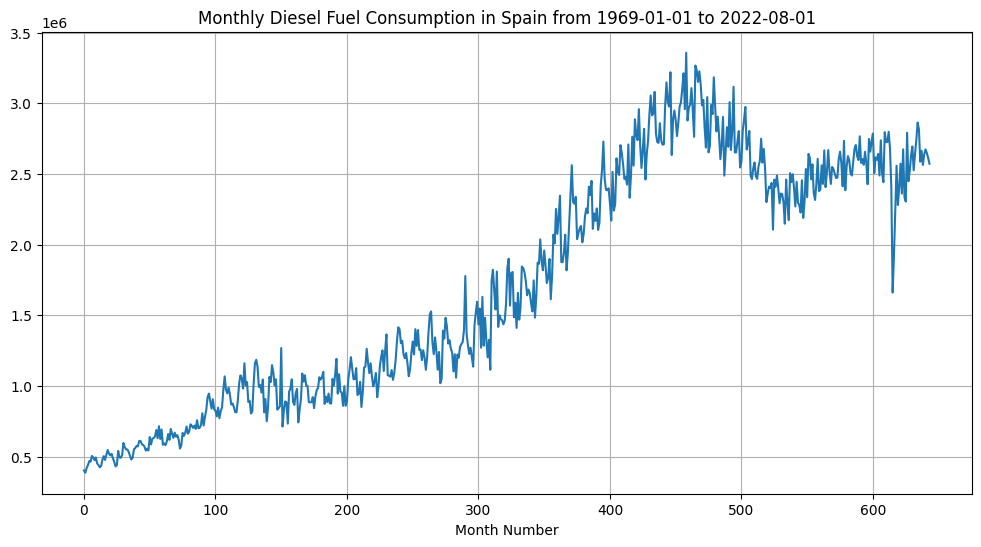

In [5]:
plt.figure(figsize=(12,6))
data['Gasoleos'].plot()
plt.xlabel('Month Number')
plt.title('Monthly Diesel Fuel Consumption in Spain from 1969-01-01 to 2022-08-01')
plt.grid()

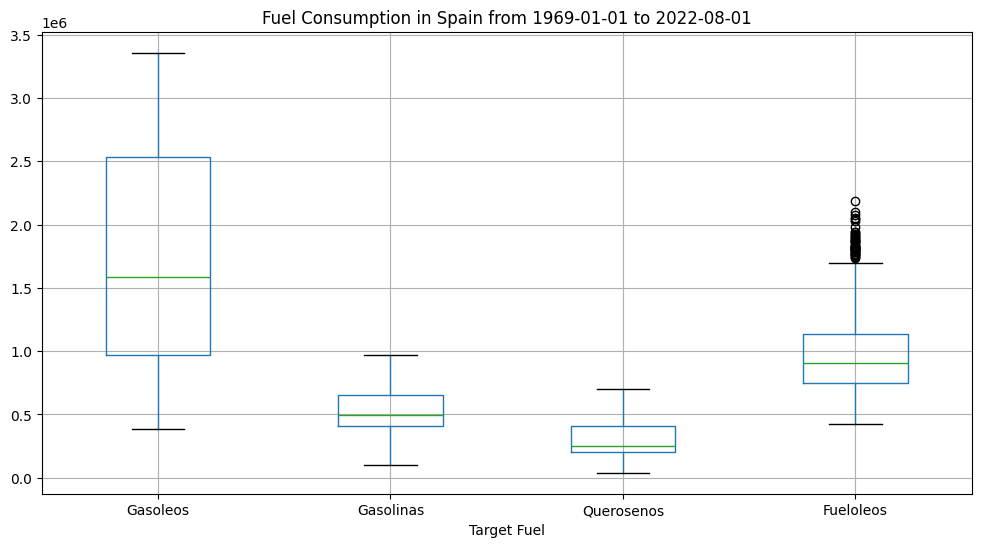

In [6]:
plt.figure(figsize=(12,6))
boxplot = data.boxplot(column=['Gasoleos', 'Gasolinas', 'Querosenos','Fueloleos']) 
plt.xlabel('Target Fuel')
plt.title('Fuel Consumption in Spain from 1969-01-01 to 2022-08-01')
plt.show()

#### Drug Expenditure

In [7]:
data = fetch_dataset(name='h2o', raw=True)
data.tail()

h2o
---
Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health
system had between 1991 and 2008.
Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice(3rd
Edition). http://pkg.robjhyndman.com/fpp3package/,https://github.com/robjhyndman
/fpp3package, http://OTexts.com/fpp3.
Shape of the dataset: (204, 2)


,x,fecha
199,0.761822,2008-02-01
200,0.649435,2008-03-01
201,0.827887,2008-04-01
202,0.816255,2008-05-01
203,0.762137,2008-06-01


In [8]:
data_ext = fetch_dataset(name='h2o_exog', raw=True)
data_ext.tail()

h2o_exog
--------
Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health
system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are
simulated.
Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd
Edition). http://pkg.robjhyndman.com/fpp3package/,
https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.
Shape of the dataset: (195, 4)


,fecha,y,exog_1,exog_2
190,2008-02-01,0.761822,1.515840,1.786373
191,2008-03-01,0.649435,1.506258,1.694264
192,2008-04-01,0.827887,1.505253,1.627135
193,2008-05-01,0.816255,1.491464,1.555068
194,2008-06-01,0.762137,1.459856,1.463507


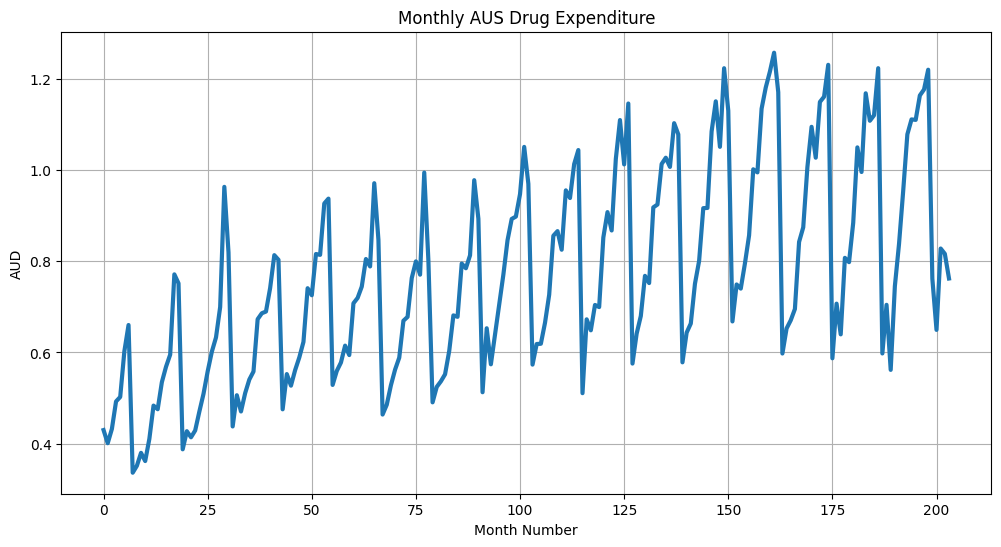

In [9]:
plt.figure(figsize=(12,6))
data['x'].plot(lw=3)
plt.xlabel('Month Number')
plt.ylabel('AUD')
plt.title('Monthly AUS Drug Expenditure')
plt.grid()

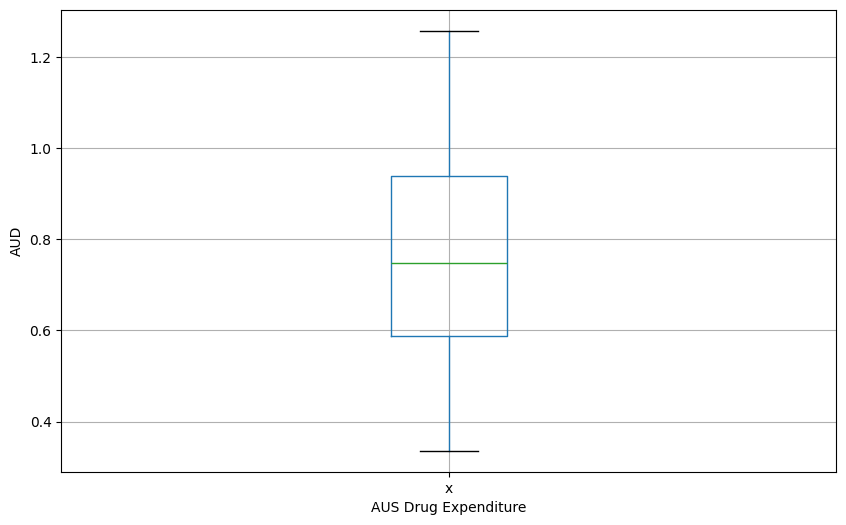

In [10]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['x']) 
plt.ylabel('AUD')
plt.xlabel('Target Fuel')
plt.xlabel('AUS Drug Expenditure')
plt.show()

#### Item Sales

In [11]:
data = fetch_dataset(name='items_sales', raw=True)
data.tail()

items_sales
-----------
Simulated time series for the sales of 3 different items.
Simulated data.
Shape of the dataset: (1097, 4)


,date,item_1,item_2,item_3
1092,2014-12-28,17.329233,18.189583,20.586030
1093,2014-12-29,19.611623,24.539583,28.127390
1094,2014-12-30,18.857026,17.677083,21.555782
1095,2014-12-31,18.721223,17.391667,18.605453
1096,2015-01-01,10.496302,21.034615,19.943717


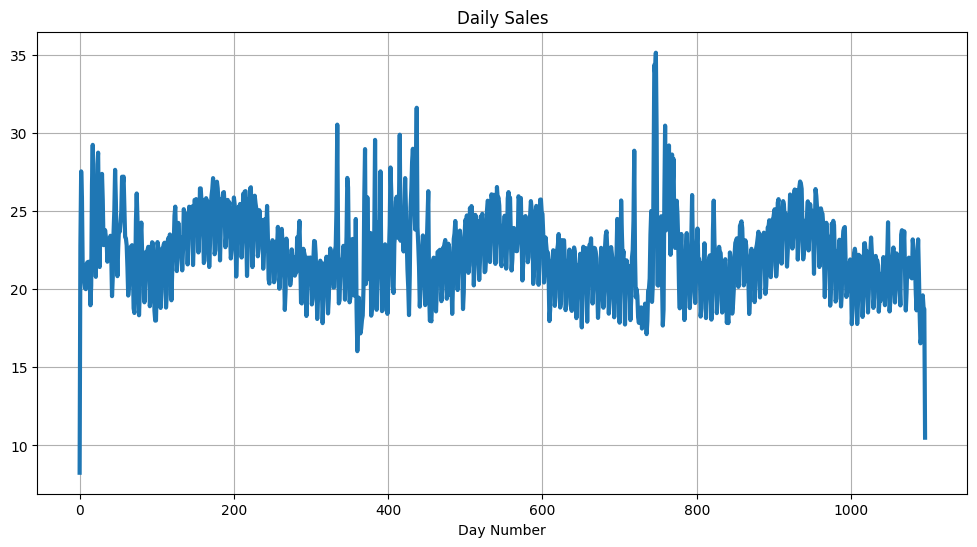

In [12]:
plt.figure(figsize=(12,6))
data['item_1'].plot(lw=3)
plt.xlabel('Day Number')

plt.title('Daily Sales')
plt.grid()

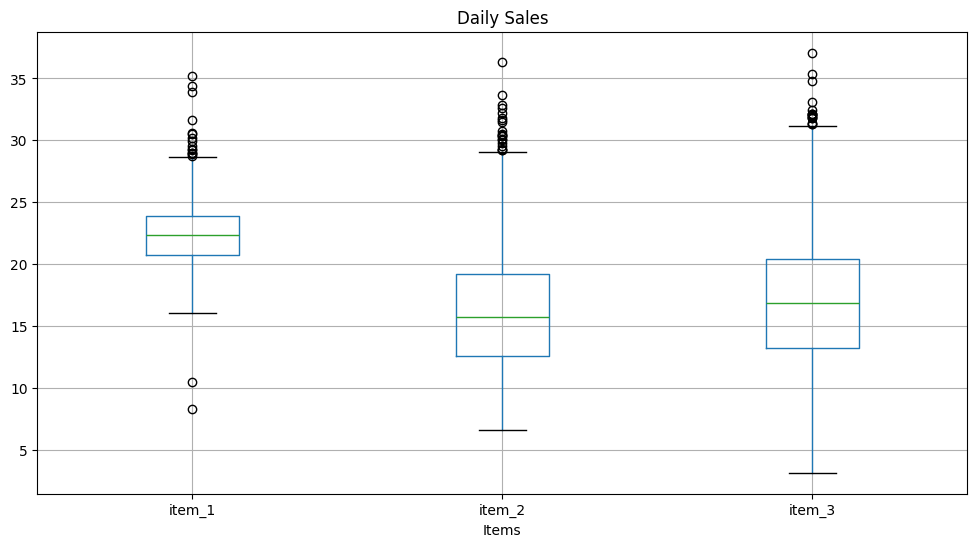

In [13]:
plt.figure(figsize=(12,6))
boxplot = data.boxplot(column=['item_1', 'item_2', 'item_3']) 
plt.xlabel('Items')
plt.title('Daily Sales')

plt.show()

#### Air Quality

In [14]:
data = fetch_dataset(name='air_quality_valencia', raw=True)
data.tail()

air_quality_valencia
--------------------
Hourly measures of several air chemical pollutant at Valencia city (Avd.
Francia) from 2019-01-01 to 20213-12-31. Including the following variables:
pm2.5 (µg/m³), CO (mg/m³), NO (µg/m³), NO2 (µg/m³), PM10 (µg/m³), NOx (µg/m³),
O3 (µg/m³), Veloc. (m/s), Direc. (degrees), SO2 (µg/m³).
Red de Vigilancia y Control de la Contaminación Atmosférica, 46250047-València -
Av. França, https://mediambient.gva.es/es/web/calidad-ambiental/datos-
historicos.
Shape of the dataset: (43824, 11)


,datetime,so2,co,no,no2,pm10,nox,o3,veloc.,direc.,pm2.5
43819,2023-12-31 19:00:00,3.0,0.1,6.0,18.0,8.0,26.0,47.0,1.7,246.0,7.0
43820,2023-12-31 20:00:00,3.0,0.1,6.0,19.0,7.0,27.0,49.0,1.3,239.0,6.0
43821,2023-12-31 21:00:00,3.0,0.1,4.0,15.0,5.0,22.0,55.0,1.5,247.0,4.0
43822,2023-12-31 22:00:00,3.0,0.1,5.0,13.0,5.0,20.0,57.0,1.1,246.0,5.0
43823,2023-12-31 23:00:00,3.0,0.1,5.0,12.0,5.0,20.0,55.0,0.5,247.0,4.0


In [15]:
data_ext = fetch_dataset(name='air_quality_valencia_no_missing', raw=True)

air_quality_valencia_no_missing
-------------------------------
Hourly measures of several air chemical pollutant at Valencia city (Avd.
Francia) from 2019-01-01 to 20213-12-31. Including the following variables:
pm2.5 (µg/m³), CO (mg/m³), NO (µg/m³), NO2 (µg/m³), PM10 (µg/m³), NOx (µg/m³),
O3 (µg/m³), Veloc. (m/s), Direc. (degrees), SO2 (µg/m³). Missing values have
been imputed using linear interpolation.
Red de Vigilancia y Control de la Contaminación Atmosférica, 46250047-València -
Av. França, https://mediambient.gva.es/es/web/calidad-ambiental/datos-
historicos.
Shape of the dataset: (43824, 11)


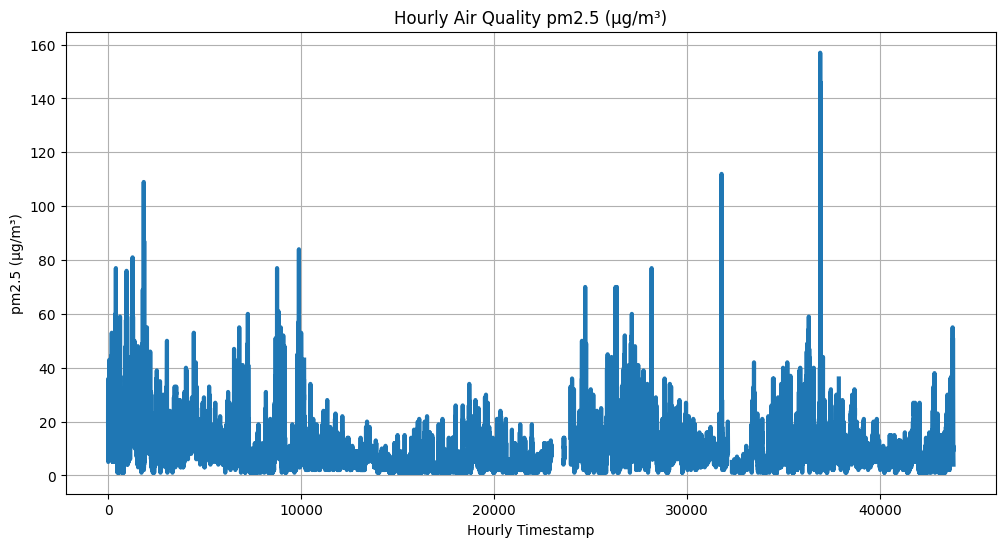

In [16]:
plt.figure(figsize=(12,6))
data['pm2.5'].plot(lw=3)
plt.xlabel('Hourly Timestamp')
plt.ylabel('pm2.5 (µg/m³)')
plt.title('Hourly Air Quality pm2.5 (µg/m³)')
plt.grid()

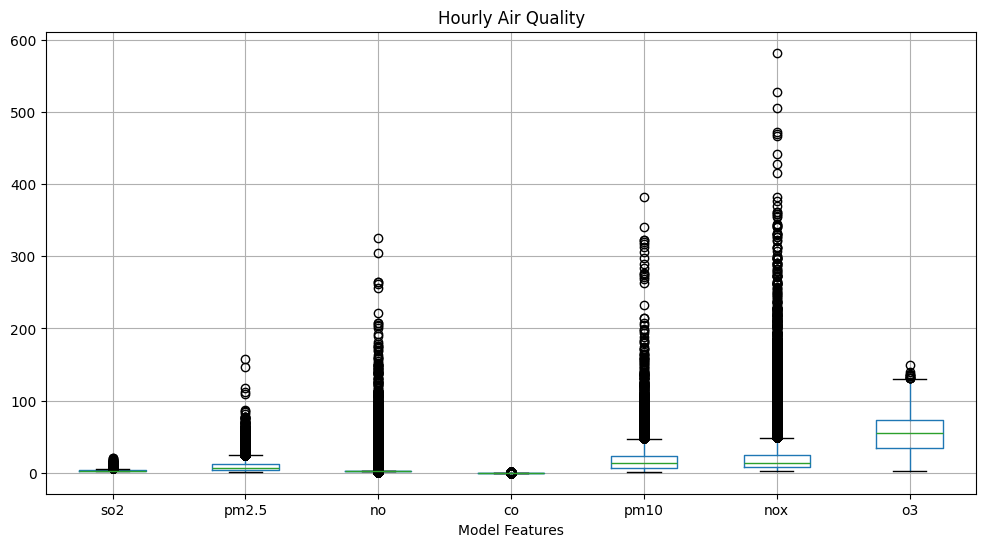

In [17]:
plt.figure(figsize=(12,6))
boxplot = data.boxplot(column=['so2', 'pm2.5', 'no','co','pm10','nox','o3']) 
plt.xlabel('Model Features')
plt.title('Hourly Air Quality')
plt.show()

In [18]:
# Fill diagonal and upper half with NaNs
corr = data.cov(numeric_only=True)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr[mask] = np.nan
(corr
 .style
 .background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1)
 .highlight_null(color='#f1f1f1')  # Color NaNs grey
 .format(precision=2))

,so2,co,no,no2,pm10,nox,o3,veloc.,direc.,pm2.5
so2,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
co,0.01,nan,nan,nan,nan,nan,nan,nan,nan,nan
no,3.34,0.16,nan,nan,nan,nan,nan,nan,nan,nan
no2,2.76,0.19,95.09,nan,nan,nan,nan,nan,nan,nan
pm10,0.86,0.06,58.50,98.26,nan,nan,nan,nan,nan,nan
nox,7.88,0.43,291.76,369.55,188.30,nan,nan,nan,nan,nan
o3,-3.05,-0.28,-113.04,-257.75,-116.23,-432.29,nan,nan,nan,nan
veloc.,-0.10,-0.01,-2.74,-9.03,-1.86,-13.27,24.02,nan,nan,nan
direc.,4.92,0.27,126.90,280.50,84.87,478.25,-1136.07,-58.42,nan,nan
pm2.5,1.12,0.08,31.98,59.02,98.68,108.37,-79.05,-2.74,6.73,nan


In [19]:
# Fill diagonal and upper half with NaNs
corr = data.corr(numeric_only=True)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr[mask] = np.nan
(corr
 .style
 .background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1)
 .highlight_null(color='#f1f1f1')  # Color NaNs grey
 .format(precision=2))

,so2,co,no,no2,pm10,nox,o3,veloc.,direc.,pm2.5
so2,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
co,0.16,nan,nan,nan,nan,nan,nan,nan,nan,nan
no,0.25,0.24,nan,nan,nan,nan,nan,nan,nan,nan
no2,0.16,0.21,0.56,nan,nan,nan,nan,nan,nan,nan
pm10,0.04,0.06,0.30,0.38,nan,nan,nan,nan,nan,nan
nox,0.23,0.25,0.90,0.86,0.38,nan,nan,nan,nan,nan
o3,-0.09,-0.18,-0.37,-0.64,-0.25,-0.56,nan,nan,nan,nan
veloc.,-0.05,-0.13,-0.14,-0.34,-0.06,-0.26,0.51,nan,nan,nan
direc.,0.04,0.04,0.11,0.18,0.05,0.16,-0.41,-0.32,nan,nan
pm2.5,0.11,0.17,0.33,0.46,0.69,0.44,-0.34,-0.18,0.01,nan


#### Website Visits

In [20]:
data = fetch_dataset(name='website_visits', raw=True)
data.tail()

website_visits
--------------
Daily visits to the cienciadedatos.net website registered with the google
analytics service.
Amat Rodrigo, J. (2021). cienciadedatos.net (1.0.0). Zenodo.
https://doi.org/10.5281/zenodo.10006330
Shape of the dataset: (421, 2)


,date,users
416,21/8/21,1546
417,22/8/21,1393
418,23/8/21,2371
419,24/8/21,2547
420,25/8/21,2448


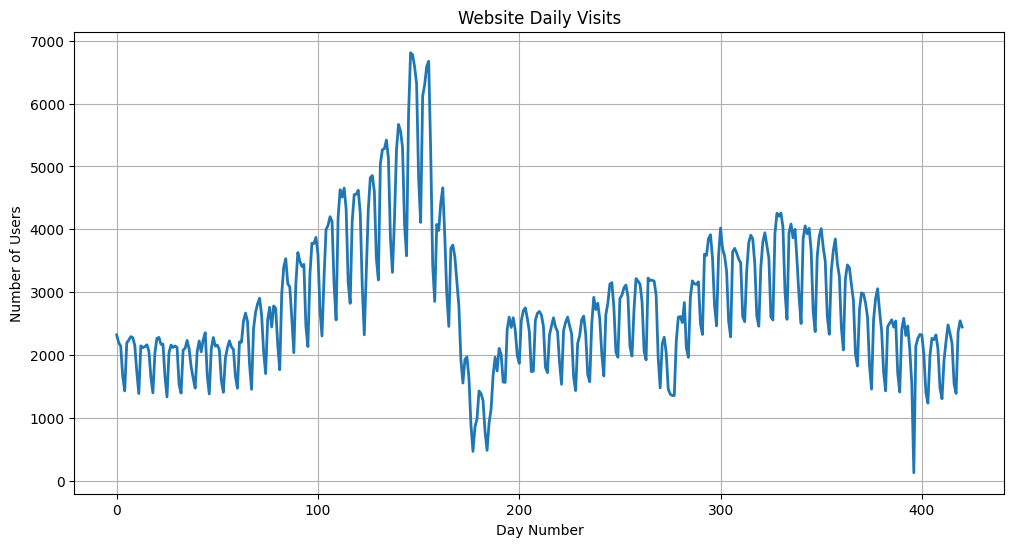

In [21]:
plt.figure(figsize=(12,6))
data['users'].plot(lw=2)
plt.xlabel('Day Number')
plt.ylabel('Number of Users')
plt.title('Website Daily Visits')
plt.grid()

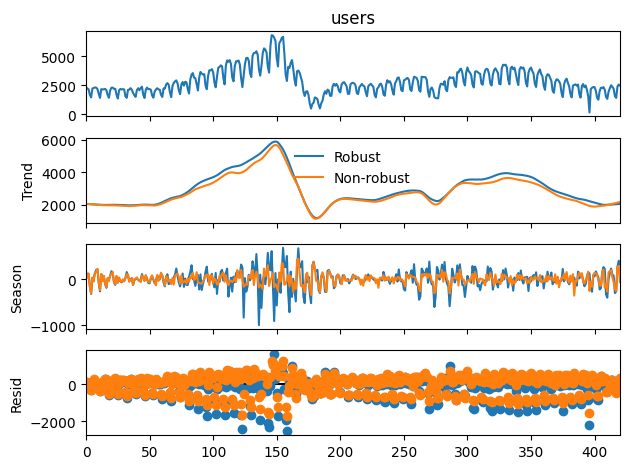

In [22]:
from statsmodels.tsa.seasonal import STL

def add_stl_plot(fig, res, legend):
    """Add 3 plots from a second STL fit"""
    axs = fig.get_axes()
    comps = ["trend", "seasonal", "resid"]
    for ax, comp in zip(axs[1:], comps):
        series = getattr(res, comp)
        if comp == "resid":
            ax.plot(series, marker="o", linestyle="none")
        else:
            ax.plot(series)
            if comp == "trend":
                ax.legend(legend, frameon=False)
elec_equip=data['users']
stl = STL(elec_equip, period=12, robust=True)
res_robust = stl.fit()
fig = res_robust.plot()
res_non_robust = STL(elec_equip, period=12, robust=False).fit()
add_stl_plot(fig, res_non_robust, ["Robust", "Non-robust"])

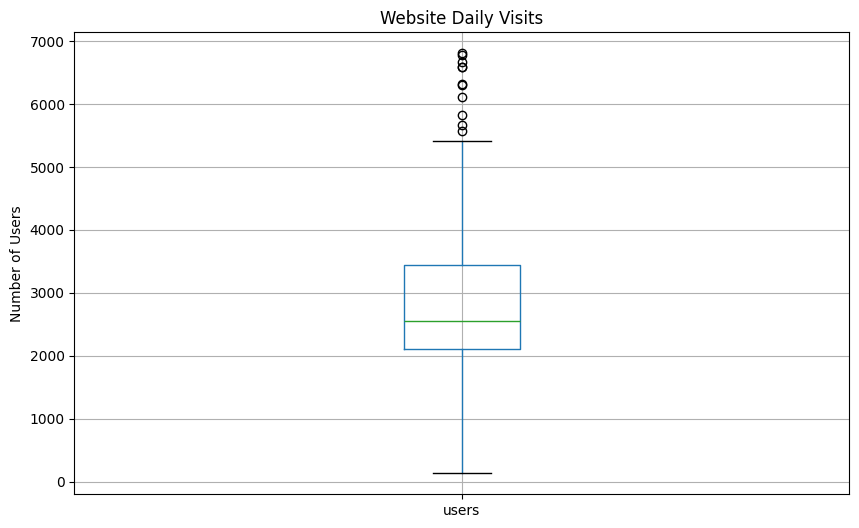

In [23]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['users']) 
plt.ylabel('Number of Users')

plt.title('Website Daily Visits')

plt.show()

#### Bike Sharing

In [24]:
data = fetch_dataset(name='bike_sharing', raw=True)
data.tail()

bike_sharing
------------
Hourly usage of the bike share system in the city of Washington D.C. during the
years 2011 and 2012. In addition to the number of users per hour, information
about weather conditions and holidays is available.
Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.
https://doi.org/10.24432/C5W894.
Shape of the dataset: (17544, 12)


,date_time,holiday,workingday,weather,temp,atemp,hum,windspeed,users,month,hour,weekday
17539,2012-12-31 19:00:00,0.0,1.0,mist,10.66,12.880,60.0,11.0014,119.0,12,19,0
17540,2012-12-31 20:00:00,0.0,1.0,mist,10.66,12.880,60.0,11.0014,89.0,12,20,0
17541,2012-12-31 21:00:00,0.0,1.0,clear,10.66,12.880,60.0,11.0014,90.0,12,21,0
17542,2012-12-31 22:00:00,0.0,1.0,clear,10.66,13.635,56.0,8.9981,61.0,12,22,0
17543,2012-12-31 23:00:00,0.0,1.0,clear,10.66,13.635,65.0,8.9981,49.0,12,23,0


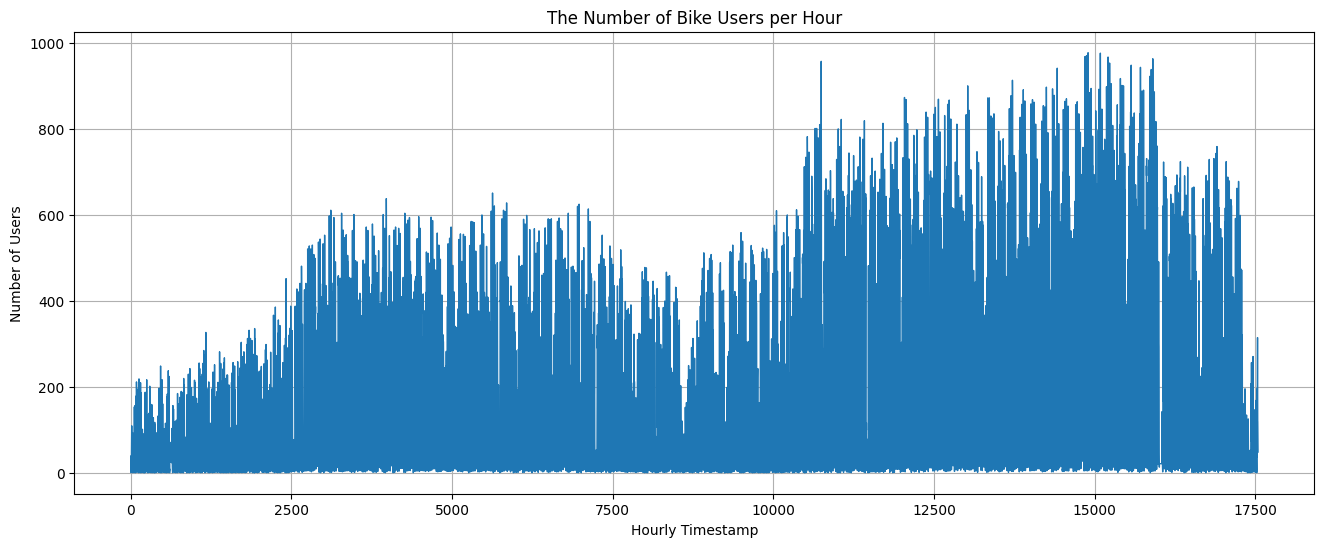

In [25]:
plt.figure(figsize=(16,6))
data['users'].plot(lw=1)
plt.xlabel('Hourly Timestamp')
plt.ylabel('Number of Users')
plt.title('The Number of Bike Users per Hour')
plt.grid()

In [26]:
# Fill diagonal and upper half with NaNs
data1 = data[['users','temp','hum','windspeed']]
corr = data1.corr(numeric_only=True)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr[mask] = np.nan
(corr
 .style
 .background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1)
 .highlight_null(color='#f1f1f1')  # Color NaNs grey
 .format(precision=2))

,users,temp,hum,windspeed
users,nan,nan,nan,nan
temp,0.41,nan,nan,nan
hum,-0.33,-0.07,nan,nan
windspeed,0.08,-0.02,-0.27,nan


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date_time   17544 non-null  object 
 1   holiday     17544 non-null  float64
 2   workingday  17544 non-null  float64
 3   weather     17544 non-null  object 
 4   temp        17544 non-null  float64
 5   atemp       17544 non-null  float64
 6   hum         17544 non-null  float64
 7   windspeed   17544 non-null  float64
 8   users       17544 non-null  float64
 9   month       17544 non-null  int64  
 10  hour        17544 non-null  int64  
 11  weekday     17544 non-null  int64  
dtypes: float64(7), int64(3), object(2)
memory usage: 1.6+ MB


In [28]:
data_ext = fetch_dataset(name='bike_sharing_extended_features', raw=True)
data_ext.tail()

bike_sharing_extended_features
------------------------------
Hourly usage of the bike share system in the city of Washington D.C. during the
years 2011 and 2012. In addition to the number of users per hour, the dataset
was enriched by introducing supplementary features. Addition includes calendar-
based variables (day of the week, hour of the day, month, etc.), indicators for
sunlight, incorporation of rolling temperature averages, and the creation of
polynomial features generated from variable pairs. All cyclic variables are
encoded using sine and cosine functions to ensure accurate representation.
Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.
https://doi.org/10.24432/C5W894.
Shape of the dataset: (17352, 91)


,date_time,users,weather,month_sin,month_cos,week_of_year_sin,week_of_year_cos,week_day_sin,week_day_cos,hour_day_sin,...,temp_roll_mean_1_day,temp_roll_mean_7_day,temp_roll_max_1_day,temp_roll_min_1_day,temp_roll_max_7_day,temp_roll_min_7_day,holiday_previous_day,holiday_next_day,temp,holiday
17347,2012-12-30 19:00:00,102.0,clear,-2.449294e-16,1.0,6.432491e-16,1.0,-2.449294e-16,1.0,-8.660254e-01,...,10.899167,10.455000,12.30,9.84,16.4,7.38,0.0,0.0,13.94,0.0
17348,2012-12-30 20:00:00,72.0,clear,-2.449294e-16,1.0,6.432491e-16,1.0,-2.449294e-16,1.0,-7.071068e-01,...,10.967500,10.464762,13.94,9.84,16.4,7.38,0.0,0.0,9.02,0.0
17349,2012-12-30 21:00:00,47.0,clear,-2.449294e-16,1.0,6.432491e-16,1.0,-2.449294e-16,1.0,-5.000000e-01,...,10.830833,10.455000,13.94,9.02,16.4,7.38,0.0,0.0,8.20,0.0
17350,2012-12-30 22:00:00,36.0,clear,-2.449294e-16,1.0,6.432491e-16,1.0,-2.449294e-16,1.0,-2.588190e-01,...,10.694167,10.445238,13.94,8.20,16.4,7.38,0.0,0.0,8.20,0.0
17351,2012-12-30 23:00:00,49.0,clear,-2.449294e-16,1.0,6.432491e-16,1.0,-2.449294e-16,1.0,-2.449294e-16,...,10.591666,10.435476,13.94,8.20,16.4,7.38,0.0,0.0,8.20,0.0


In [29]:
data_ext.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17352 entries, 0 to 17351
Data columns (total 91 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   date_time                                17352 non-null  object 
 1   users                                    17352 non-null  float64
 2   weather                                  17352 non-null  object 
 3   month_sin                                17352 non-null  float64
 4   month_cos                                17352 non-null  float64
 5   week_of_year_sin                         17352 non-null  float64
 6   week_of_year_cos                         17352 non-null  float64
 7   week_day_sin                             17352 non-null  float64
 8   week_day_cos                             17352 non-null  float64
 9   hour_day_sin                             17352 non-null  float64
 10  hour_day_cos                             17352

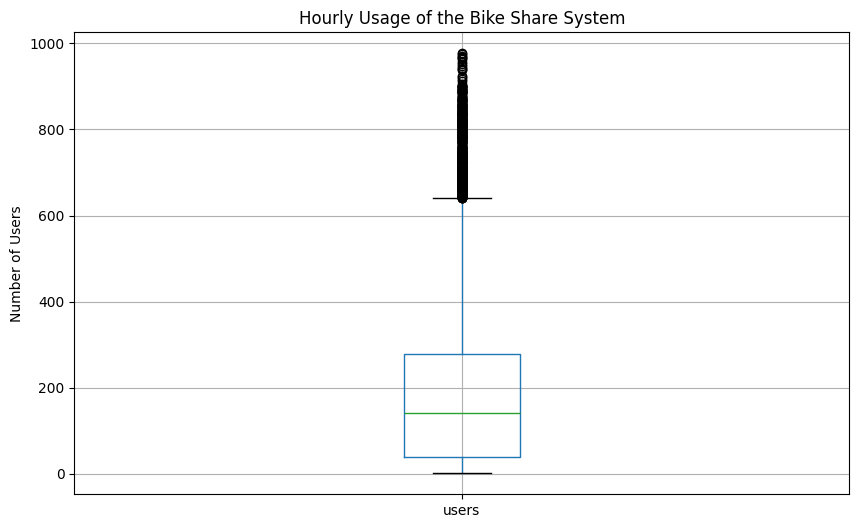

In [30]:
plt.figure(figsize=(10,6))
boxplot = data1.boxplot(column=['users']) 
plt.ylabel('Number of Users')
plt.title('Hourly Usage of the Bike Share System')

plt.show()

#### Australia Tourism

In [31]:
data = fetch_dataset(name='australia_tourism', raw=True)
data.tail()

australia_tourism
-----------------
Quarterly overnight trips (in thousands) from 1998 Q1 to 2016 Q4 across
Australia. The tourism regions are formed through the aggregation of Statistical
Local Areas (SLAs) which are defined by the various State and Territory tourism
authorities according to their research and marketing needs.
Wang, E, D Cook, and RJ Hyndman (2020). A new tidy data structure to support
exploration and modeling of temporal data, Journal of Computational and
Graphical Statistics, 29:3, 466-478, doi:10.1080/10618600.2019.1695624.
Shape of the dataset: (24320, 5)


,date_time,Region,State,Purpose,Trips
24315,2016-10-01,Yorke Peninsula,South Australia,Visiting,33.672151
24316,2017-01-01,Yorke Peninsula,South Australia,Visiting,46.223014
24317,2017-04-01,Yorke Peninsula,South Australia,Visiting,50.582837
24318,2017-07-01,Yorke Peninsula,South Australia,Visiting,27.766728
24319,2017-10-01,Yorke Peninsula,South Australia,Visiting,46.281578


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24320 entries, 0 to 24319
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date_time  24320 non-null  object 
 1   Region     24320 non-null  object 
 2   State      24320 non-null  object 
 3   Purpose    24320 non-null  object 
 4   Trips      24320 non-null  float64
dtypes: float64(1), object(4)
memory usage: 950.1+ KB


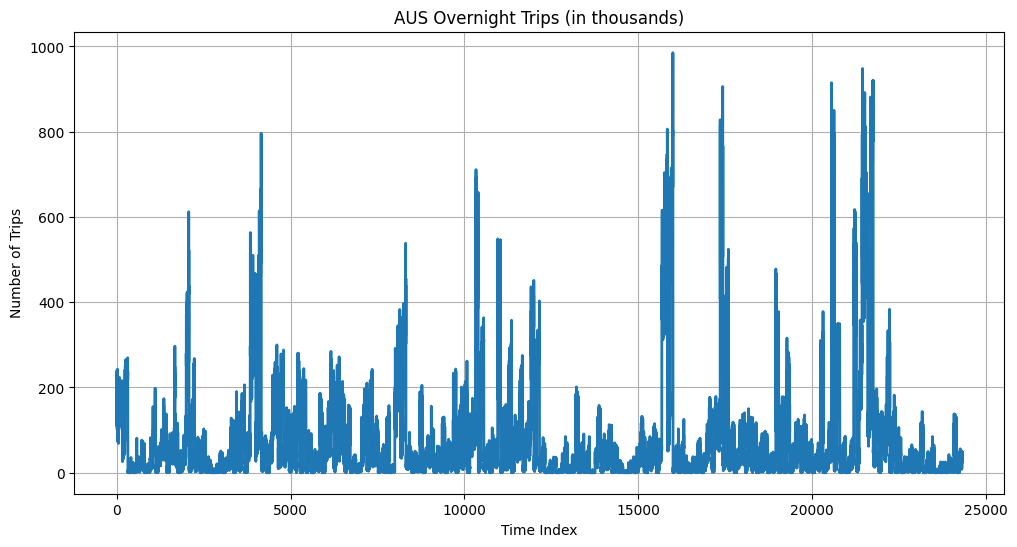

In [33]:
plt.figure(figsize=(12,6))
data['Trips'].plot(lw=2)
plt.xlabel('Time Index')
plt.ylabel('Number of Trips')
plt.title('AUS Overnight Trips (in thousands)')
plt.grid()

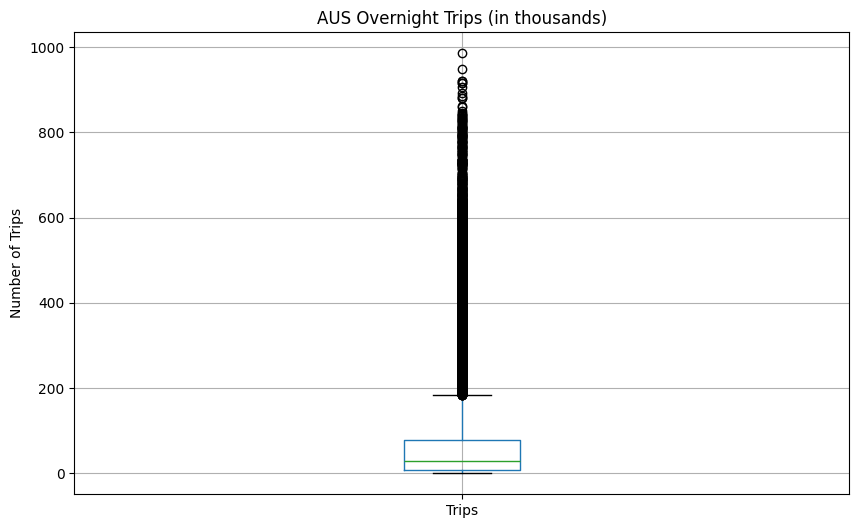

In [34]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['Trips']) 
plt.ylabel('Number of Trips')
plt.title('AUS Overnight Trips (in thousands)')

plt.show()

#### UK Daily Flights

In [35]:
data = fetch_dataset(name='uk_daily_flights', raw=True)
data.tail()

uk_daily_flights
----------------
Daily number of flights in UK from 02/01/2019 to 23/01/2022.
Experimental statistics published as part of the Economic activity and social
change in the UK, real-time indicators release, Published 27 January 2022. Daily
flight numbers are available in the dashboard provided by the European
Organisation for the Safety of Air Navigation (EUROCONTROL). https://www.ons.gov
.uk/economy/economicoutputandproductivity/output/bulletins/economicactivityandso
cialchangeintheukrealtimeindicators/latest
Shape of the dataset: (1118, 2)


,Date,Number of flights
1113,19/01/2022,2084
1114,20/01/2022,2408
1115,21/01/2022,2801
1116,22/01/2022,2361
1117,23/01/2022,2696


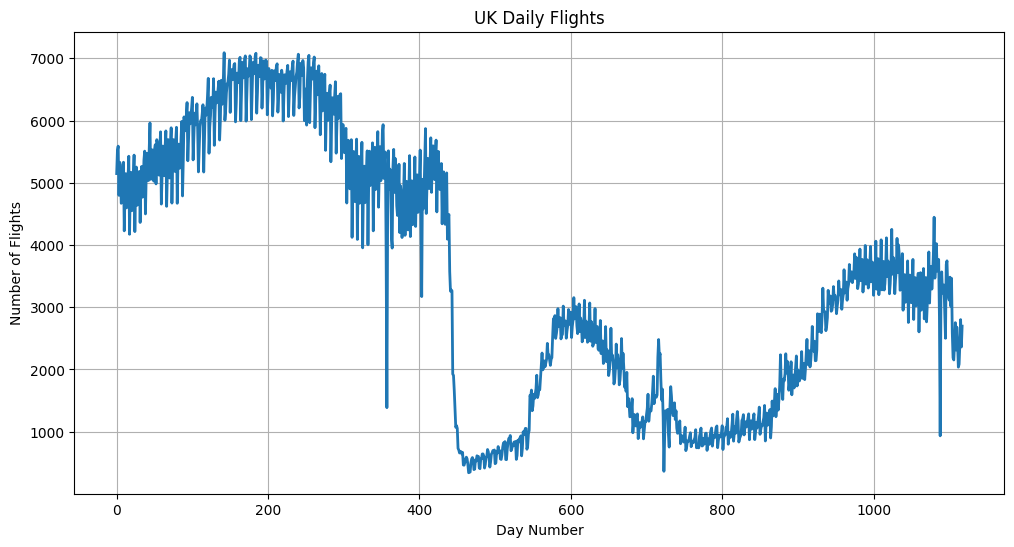

In [36]:
plt.figure(figsize=(12,6))
data['Number of flights'].plot(lw=2)
plt.xlabel('Day Number')
plt.ylabel('Number of Flights')
plt.title('UK Daily Flights')
plt.grid()

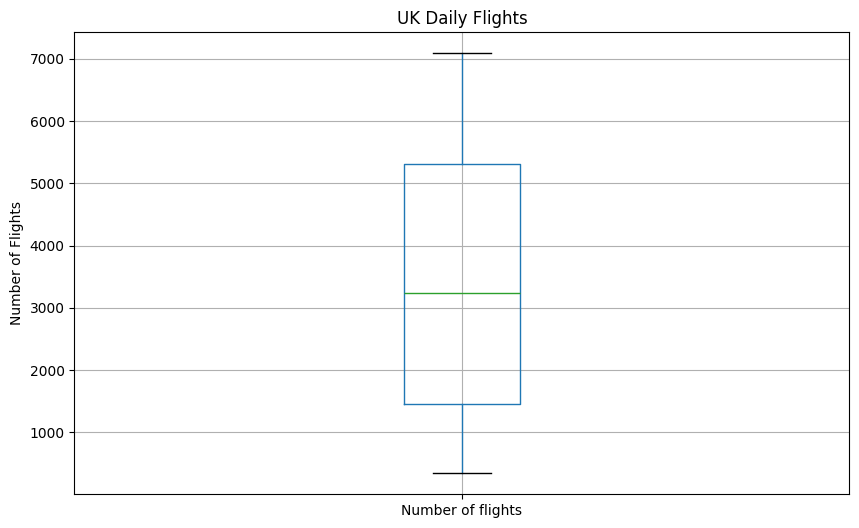

In [37]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['Number of flights']) 
plt.ylabel('Number of Flights')
plt.title('UK Daily Flights')

plt.show()

#### Wiki Visits

In [38]:
data = fetch_dataset(name='wikipedia_visits', raw=True)
data.tail()

wikipedia_visits
----------------
Log daily page views for the Wikipedia page for Peyton Manning. Scraped data
using the Wikipediatrend package in R.
https://github.com/facebook/prophet/blob/main/examples/example_wp_log_peyton_man
ning.csv
Shape of the dataset: (2905, 2)


,date,y
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871
2904,2016-01-20,8.891374


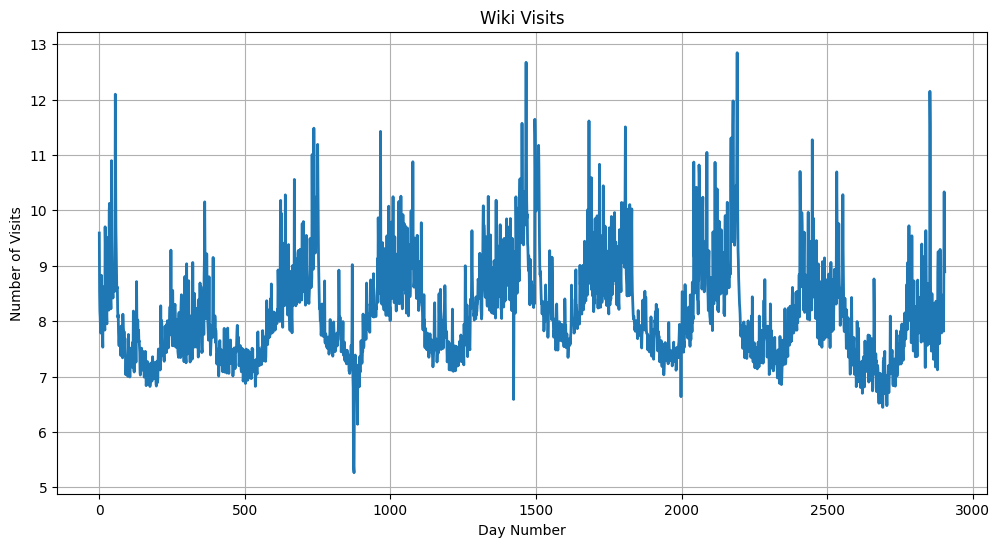

In [39]:
plt.figure(figsize=(12,6))
data['y'].plot(lw=2)
plt.xlabel('Day Number')
plt.ylabel('Number of Visits')
plt.title('Wiki Visits')
plt.grid()

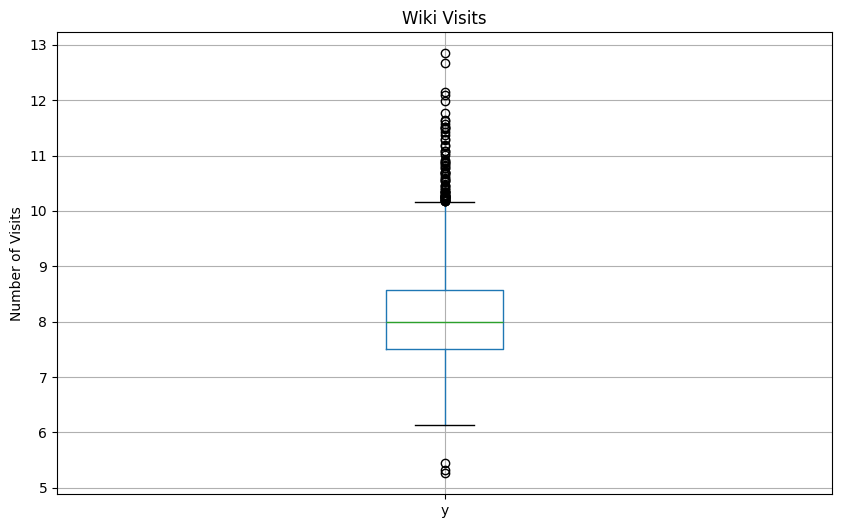

In [40]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['y']) 
plt.ylabel('Number of Visits')
plt.title('Wiki Visits')

plt.show()

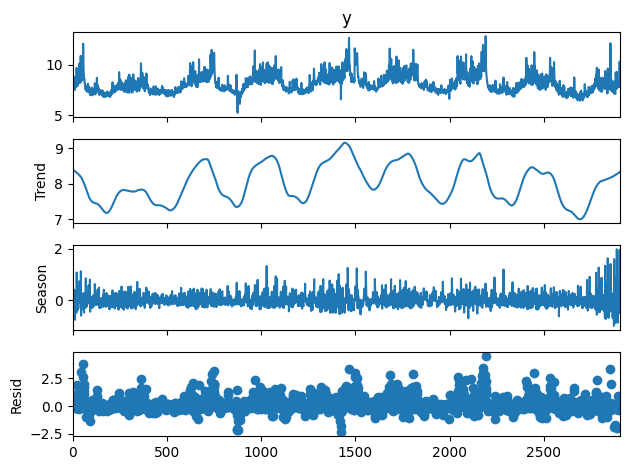

In [41]:
from statsmodels.tsa.seasonal import STL

co2 = data['y']
stl = STL(co2, period=48, robust=True)
res = stl.fit()
fig = res.plot()

#### Electricity Demand

In [42]:
data = fetch_dataset(name='vic_electricity', raw=True)
data.tail()

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 5)


,Time,Demand,Temperature,Date,Holiday
52603,2014-12-31T10:30:00Z,3873.448714,19.0,2014-12-31,False
52604,2014-12-31T11:00:00Z,3791.637322,18.5,2014-12-31,False
52605,2014-12-31T11:30:00Z,3724.835666,17.7,2014-12-31,False
52606,2014-12-31T12:00:00Z,3761.886854,17.3,2014-12-31,False
52607,2014-12-31T12:30:00Z,3809.414586,17.1,2014-12-31,False


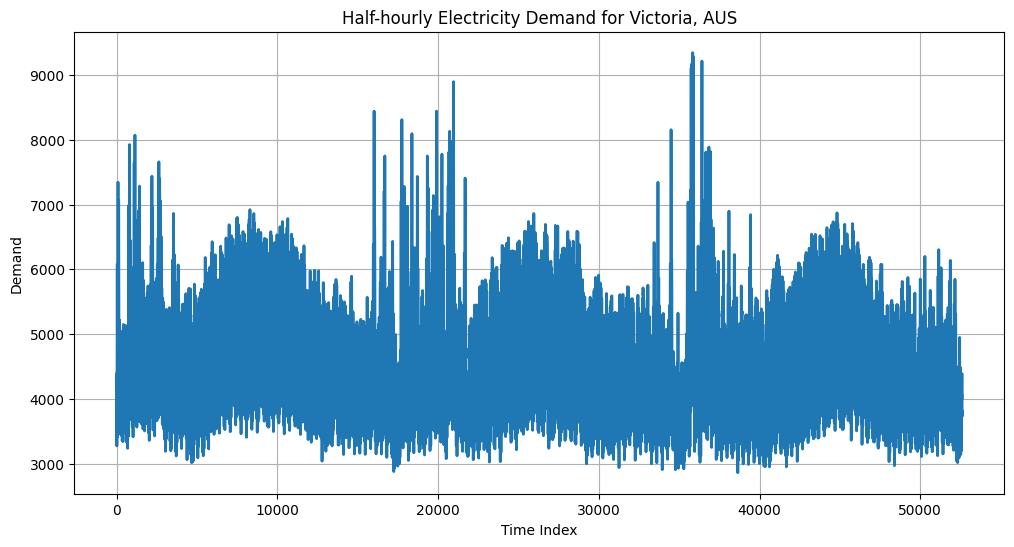

In [43]:
plt.figure(figsize=(12,6))
data['Demand'].plot(lw=2)
plt.xlabel('Time Index')
plt.ylabel('Demand')
plt.title('Half-hourly Electricity Demand for Victoria, AUS')
plt.grid()

Text(0.5, 1.0, 'Half-hourly Electricity Demand for Victoria, AUS')

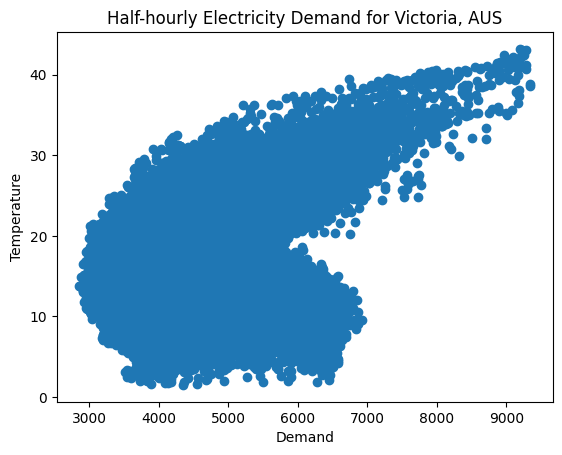

In [44]:
plt.scatter(data['Demand'],data['Temperature'])
plt.xlabel('Demand')
plt.ylabel('Temperature')
plt.title('Half-hourly Electricity Demand for Victoria, AUS')

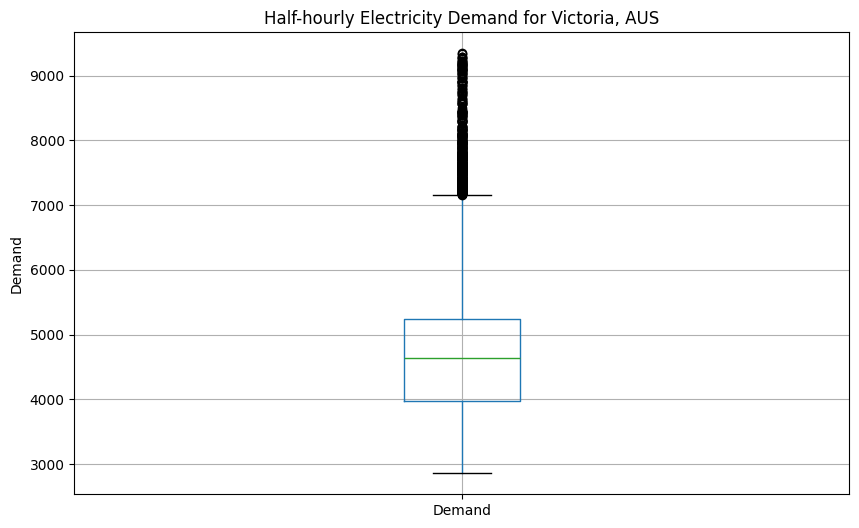

In [45]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['Demand']) 
plt.ylabel('Demand')
plt.title('Half-hourly Electricity Demand for Victoria, AUS')

plt.show()

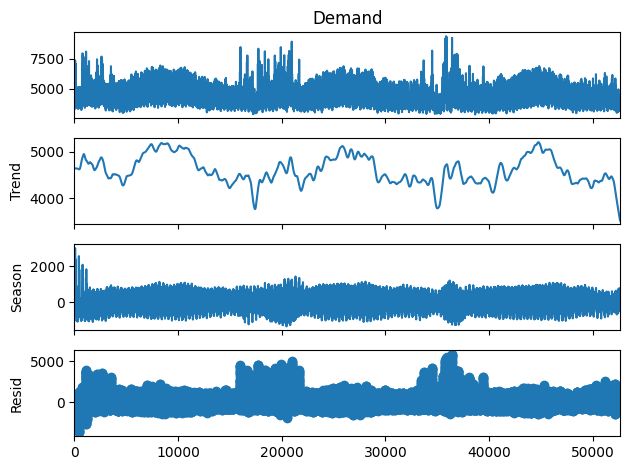

In [46]:
from statsmodels.tsa.seasonal import STL
co2 = data['Demand']
stl = STL(co2, period=360, robust=True)
res = stl.fit()
fig = res.plot()

#### Store Sales

In [47]:
data = fetch_dataset(name='store_sales', raw=True)
data.tail()

store_sales
-----------
This dataset contains 913,000 sales transactions from 2013-01-01 to 2017-12-31
for 50 products (SKU) in 10 stores.
The original data was obtained from: inversion. (2018). Store Item Demand
Forecasting Challenge. Kaggle. https://kaggle.com/competitions/demand-
forecasting-kernels-only
Shape of the dataset: (913000, 4)


,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


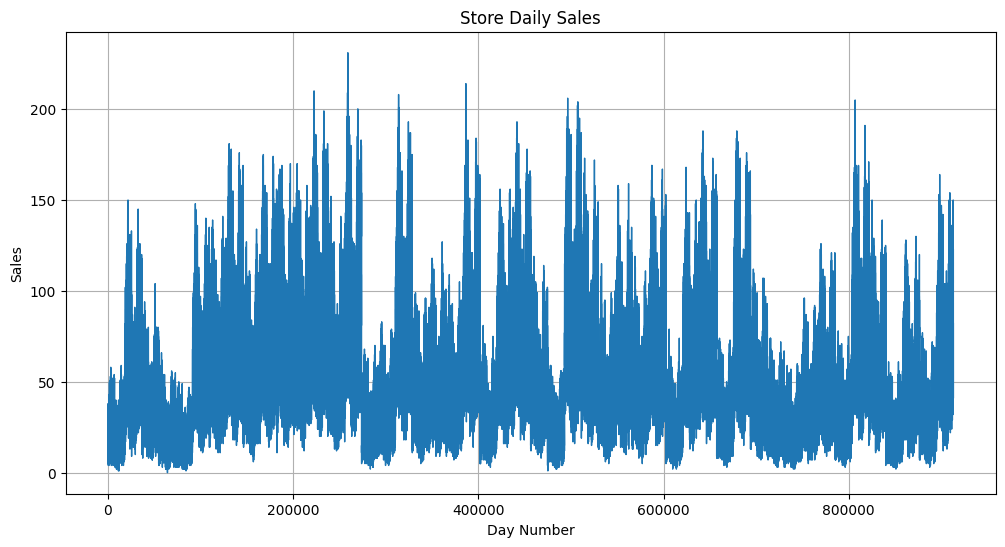

In [48]:
plt.figure(figsize=(12,6))
data['sales'].plot(lw=1)
plt.xlabel('Day Number')
plt.ylabel('Sales')
plt.title('Store Daily Sales')
plt.grid()

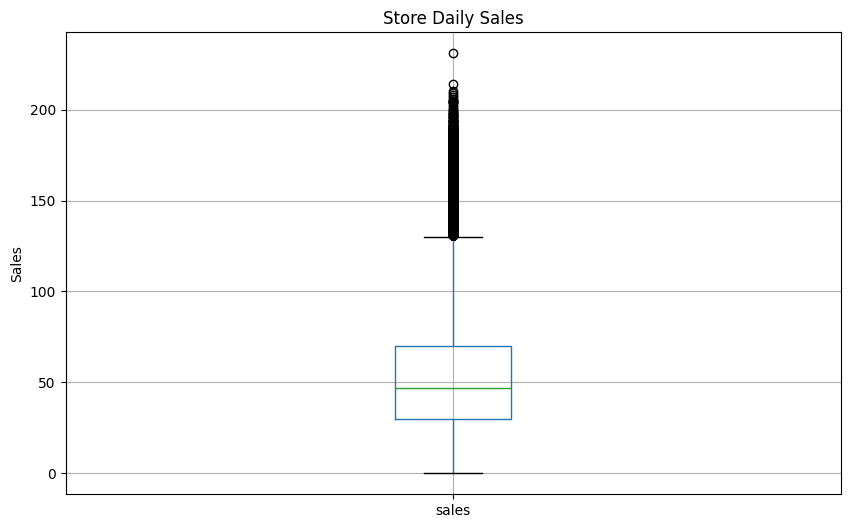

In [49]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['sales']) 
plt.ylabel('Sales')
plt.title('Store Daily Sales')

plt.show()

In [ ]:
from statsmodels.tsa.seasonal import STL
co2 = data['sales']
stl = STL(co2, period=120, robust=True, seasonal=13)
res = stl.fit()
fig = res.plot()

#### Bicycle Rentals

In [53]:
data = fetch_dataset(name='bicimad', raw=True)
data.tail()

bicimad
-------
This dataset contains the daily users of the bicycle rental service (BiciMad) in
the city of Madrid (Spain) from 2014-06-23 to 2022-09-30.
The original data was obtained from: Portal de datos abiertos del Ayuntamiento
de Madrid https://datos.madrid.es/portal/site/egob
Shape of the dataset: (3022, 2)


,date,users
3017,2022-09-26,12340
3018,2022-09-27,13888
3019,2022-09-28,14239
3020,2022-09-29,11574
3021,2022-09-30,12957


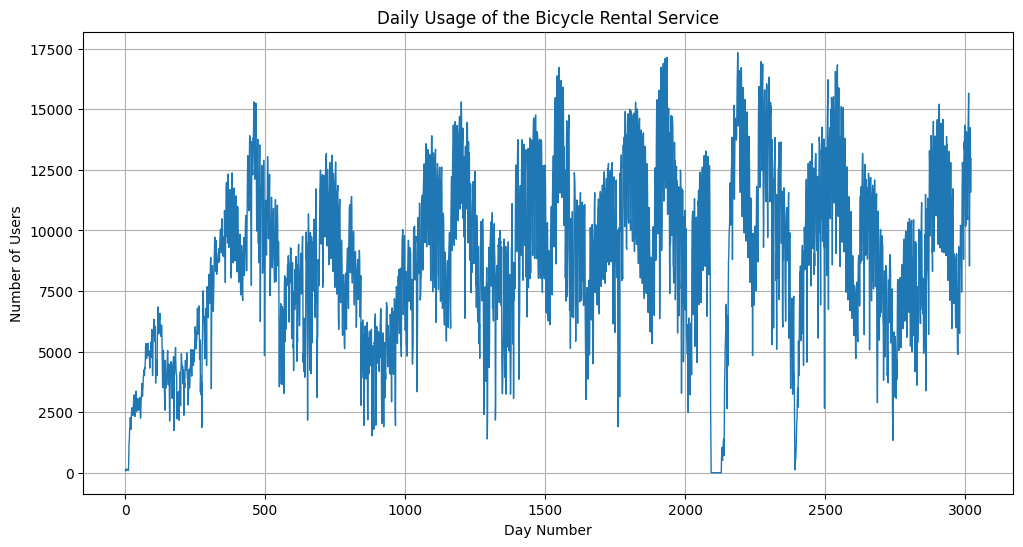

In [54]:
plt.figure(figsize=(12,6))
data['users'].plot(lw=1)
plt.xlabel('Day Number')
plt.ylabel('Number of Users')
plt.title('Daily Usage of the Bicycle Rental Service')
plt.grid()

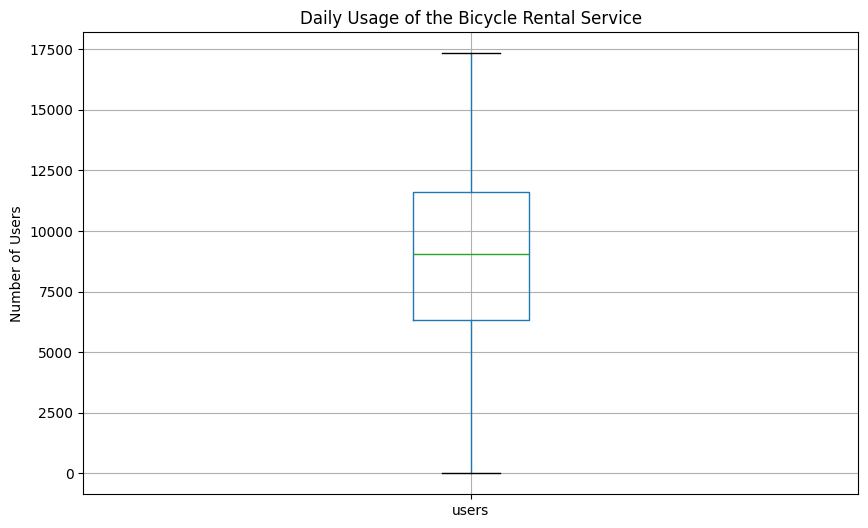

In [55]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['users']) 
plt.ylabel('Number of Users')
plt.title('Daily Usage of the Bicycle Rental Service')

plt.show()

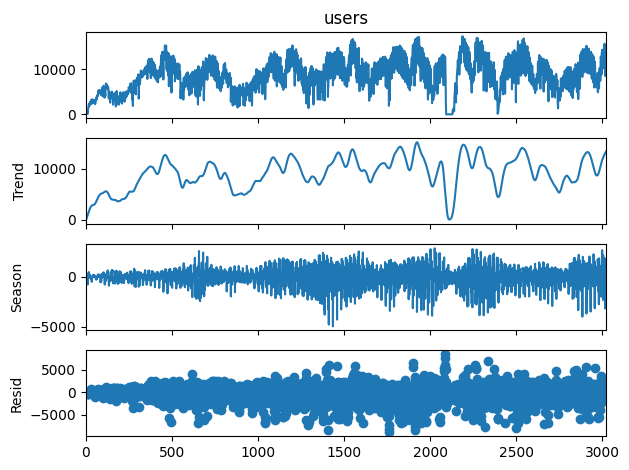

In [56]:
from statsmodels.tsa.seasonal import STL
co2 = data['users']
stl = STL(co2, period=24, robust=True)
res = stl.fit()
fig = res.plot()

#### M4 TSF Competition

In [57]:
data = fetch_dataset(name='m4_daily', raw=True)
data.tail()

ValueError: Error reading dataset 'm4_daily' from https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/m4_daily.parquet. Try to version = 'latest'

In [ ]:
plt.figure(figsize=(12,6))
data['value'].plot(lw=1)
plt.xlabel('Time Index')
plt.ylabel('Value')
plt.title('M4 Competition: Daily Time Series')
plt.grid()

In [ ]:
data_h = fetch_dataset(name='m4_hourly', raw=True)
data_h.tail()

In [ ]:
plt.figure(figsize=(12,6))
data_h['value'].plot(lw=1)
plt.xlabel('Time Index')
plt.ylabel('Value')
plt.title('M4 Competition: Hourly Time Series')
plt.grid()

In [ ]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['value']) 
plt.ylabel('Value')
plt.title('M4 Competition: Daily Time Series')

plt.show()

In [ ]:
plt.figure(figsize=(10,6))
boxplot = data_h.boxplot(column=['value']) 
plt.ylabel('Value')
plt.title('M4 Competition: Hourly Time Series')

plt.show()

#### ASHRAE Energy Predictor

In [58]:
data = fetch_dataset(name='ashrae_daily', raw=True)
data.tail()

ValueError: Error reading dataset 'ashrae_daily' from https://drive.google.com/uc?id=1fMsYjfhrFLmeFjKG3jenXjDa5s984ThC. Try to version = 'latest'

In [ ]:
data.info()

In [ ]:
plt.figure(figsize=(12,6))
data['meter_reading'].plot(lw=1)
plt.xlabel('Date')
plt.ylabel('Meter Reading')
plt.title('ASHRAE Competition: Building Daily Energy Consumption')
plt.grid()

In [ ]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['meter_reading']) 
plt.ylabel('Meter Reading')
plt.title('ASHRAE Competition: Building Daily Energy Consumption')

plt.show()

In [ ]:
# Fill diagonal and upper half with NaNs
data1 = data[['meter_reading', 'square_feet','air_temperature','wind_speed','wind_direction','sea_level_pressure']]
corr = data1.corr(numeric_only=True)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr[mask] = np.nan
(corr
 .style
 .background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1)
 .highlight_null(color='#f1f1f1')  # Color NaNs grey
 .format(precision=2))

#### Energy Consumption

In [59]:
data = fetch_dataset(name='bdg2_daily', raw=True)
data.tail()

ValueError: Error reading dataset 'bdg2_daily' from https://drive.google.com/uc?id=1KHYopzclKvS1F6Gt6GoJWKnxiuZ2aqen. Try to version = 'latest'

In [ ]:
data.info()

In [ ]:
plt.figure(figsize=(12,6))
data['meter_reading'].plot(lw=1)
plt.xlabel('Time Index')
plt.ylabel('Meter Reading')
plt.title('Data Genome Project 2: The Building Daily Energy Consumption')
plt.grid()

In [ ]:
plt.figure(figsize=(10,6))
boxplot = data.boxplot(column=['meter_reading']) 
plt.ylabel('Meter Reading')
plt.title('Data Genome Project 2: The Building Daily Energy Consumption')

plt.show()

In [ ]:
# Fill diagonal and upper half with NaNs
data1 = data[['meter_reading','sqm','lat','lng','airTemperature','cloudCoverage','precipDepth1HR','seaLvlPressure','windDirection','windSpeed']]
corr = data1.corr(numeric_only=True)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr[mask] = np.nan
(corr
 .style
 .background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1)
 .highlight_null(color='#f1f1f1')  # Color NaNs grey
 .format(precision=2))